<a href="https://colab.research.google.com/github/AmazingAadi29/Repository_AG/blob/main/Titanic_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project, you will explore the famous Titanic dataset to understand how data can provide insights into the survival of passengers. You will use the Pandas library in Python to analyze and visualize the data.

*Note: Points for each section are given in [].*


In [1]:
# Import libraries [6]

# numpy
import numpy as np
# pandas
import pandas as pd
# matplotlib
import matplotlib.pyplot as plt



# Get Data
Upload `train.csv` to a Google folder named `vhs-ai-intro`. Load this file into a dataframe named `df`. [6]





In [4]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')
# access file and load into data frame
csv_file = "/content/drive/MyDrive/train.csv"
df = pd.read_csv(csv_file)

print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                  

# Explore Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Look at the output of `df.info()` above and answer the following: [8]

1. How many rows and columns does `df` have?
2. Identify the columns that have integer datatype.
3. Identify the columns containing `null` (empty) values and calculate the proportion of values that are `null`.






1. rows = 891, columns = 12
2. PassengerID, Survived, Pclass
3. Age, Cabin and Embarked all have null values as they each have less than 891 non-null count, which would be the same number of rows/entries

The Age column has 177/891 null values

The Cabin column has 787/981 null values

The Embarked column has 2/891 null values


# Data Cleaning

In [6]:
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


Explain what the above line of code is doing. You can use `df.info()` to check the changes in `df`. [2]

df.drop() does what it's name says - it drops the column that you want it to. In this case, it drops the columns 'PassengerId', 'Name', 'Ticket'. The 'axis=1' represents the columns that are being dropped. If it were 'axis=0', we would be dropping the data for the rows, not the columns.

In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)

Using the `fillna()` function, we can fill the missing values in the `Age` column with the median value of `Age`.

What does the `inplace` parameter specify in the `fillna()` function? [2]

'inplace' represents the change that is being made, which is replacing the null values with the median value. The fact that inplace=True means that the above replacement will occur.

# Data Analysis

Let's do some counting. Using `groupby` and `size()`, or otherwise:

1. Count the number of male and female passengers. (*Hint: Use `Sex` column*) [2]
2. What percentage of passengers survived? (*Hint: Use `Survived` column*) [2]


In [11]:
# Number of male & female passengers
df_Gender = df.groupby(by = 'Sex').size()
df_Gender
# females = 314, males = 577

,0
Sex,
female,314
male,577


In [12]:
# Percentage of passengers that survived
df_Survived = df.groupby(by = 'Survived').size()
df_Survived
# as can be seen, the 0 represents survived = false (died), while the 1 represents survived = true (lived)
# so the percentage of passengers that survived would be 342/891 = 38.38%

,0
Survived,
0,549
1,342


We want to see if gender played a role in the survival rates. Let us visualise the survival rates. We will combine the 2 columns `Survived` and `Sex` to answer this and use `Matplotlib` to plot the counts.

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   female  2 non-null      int64
 1   male    2 non-null      int64
dtypes: int64(2)
memory usage: 48.0 bytes


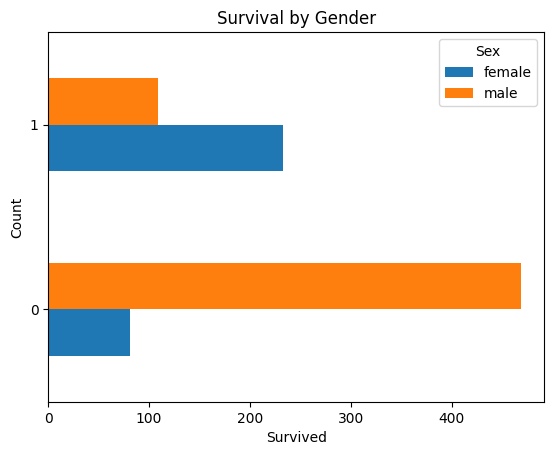

In [15]:
# Group the data by 'Survived' and 'Sex' and get the counts
survival_gender_counts = df.groupby(['Survived', 'Sex']).size().unstack()
survival_gender_counts.info()
# Plot the grouped data
survival_gender_counts.plot(kind='barh')

# Add title and labels
plt.title('Survival by Gender')
plt.xlabel('Survived')
plt.ylabel('Count')

# Show the plot
plt.show()

Let us pay attention to the code.


1.   `survival_gender_counts` holds the counts of number of survivors that are male and female. What is the type of this variable? How many rows and columns does this variable have? [2]

`survival_gender_counts` is a dataframe (df). This variable has 2 columns and 2 rows, with the columns being male and female, and the rows being survived and not survived (1 and 0)

2.   In the `survival_gender_counts.plot(kind='bar')` line, what does the `kind='bar'` parameter specify? How would the plot change if you used `kind='barh'` instead? [4]

The `kind='bar'` specifices that the shown plot will be a bar graph. If we were to use `kind='barh'`, the data would be oriented horizonatally (that's what h represents). The y-axis would be dead or alive rather than the x-axis, and this new x-axis would be the number of people who survived.

We can create the same plot with another library `Seaborn` that is built on top of `Matplotlib`.

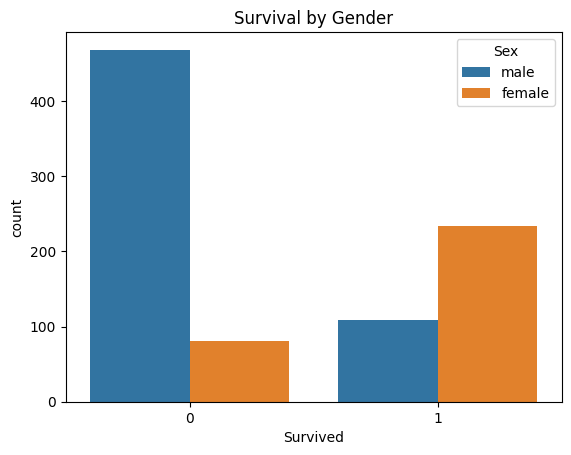

In [16]:
import seaborn as sns
sns.countplot(x='Survived', hue='Sex', data=df)

plt.title('Survival by Gender')
plt.show()

We used the function `countplot()` in `seaborn` to generate the bar plot showing the counts we need.

Explain what each of the parameters for `countplot()` specify. [6]

Parameters = x, hue, data


x specifies the name of the variable we will be using for the x-axis in order to plot the data


hue specifies uses the column name in order to give each specific column a hue - male is given blue, female is given orange


data specifies the dataframe we get the columns from. This will take the dataset needed with all the data


By looking at the plot, do you think gender and survival were related? Explain why or why not.    [3]

Yes, gender and surivival rates were related as males were more likely to die than females. This can be seen on the graph as more males died than females, while more females survived than males.

In the Titanic dataset, `Pclass` refers to the passenger class, which indicates the socioeconomic status (SES) of the passengers. There are three classes:

* 1 = First class (Upper class)
* 2 = Second class (Middle class)
* 3 = Third class (Lower class)

Using `seaborn` library, create a count plot (similar to the one above) to show the relationship between survivors and passenger class.

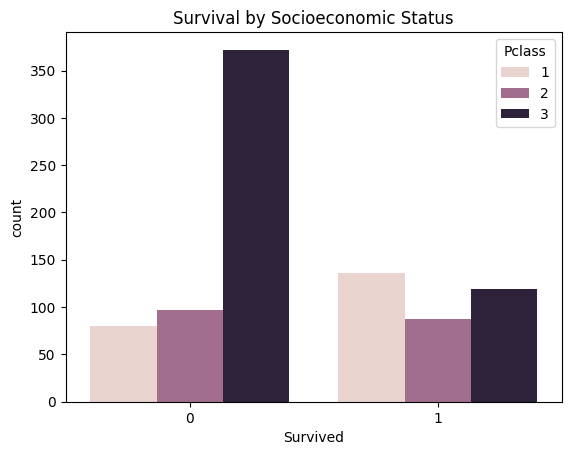

In [17]:
# Plot Survival by Passenger Class [6]
sns.countplot(x='Survived', hue='Pclass', data=df)

plt.title('Survival by Socioeconomic Status')
plt.show()

By looking at the plot, do you think passenger class and survival were related? Explain why or why not. [3]

Yes, he lower the class the more likely you were to not die. The lower class individuals had a much larger proportion of people that died. Even though the results are a bit more skewed for the survivals, this is because there were more lower classmen than other groups.